# Notebook 03 — Label Creation
## IPL 2027 Franchise Squad Predictor

**Input:** `batting_features.parquet`, `bowling_features.parquet`  
**Output:** `batting_labelled.parquet`, `bowling_labelled.parquet`

---

## Why not just use match win/loss as the label?

Virat Kohli scoring 82 in a losing RCB match is NOT a failure. Assigning label=0 to that innings poisons the model — it learns that 82 runs is a bad outcome. That's wrong.

**Our label = did the player clear their role's contribution bar AND did their team win?**

This separates individual quality from team luck.

## Label definition (calibrated to your data)

Your dataset distributions (2016–2025):
- Mean runs per innings = 21, median = 13
- Mean economy = 9.0 (average bowler leaks 9 runs/over)
- 2+ wickets occurs in 27.6% of spells

**Batting — contributed if ANY condition is true:**
- Scored 25+ runs at any strike rate, OR
- Scored 15+ runs at SR ≥ 140 (fast cameo), OR
- Scored 10+ runs in Death phase at SR ≥ 160 (finisher)

**Bowling — contributed if ANY condition is true:**
- Took 2+ wickets, OR
- Economy ≤ 8.0 bowling 3+ overs (contained the batting), OR
- Took 1+ wicket AND economy ≤ 9.0

**Final label = individual_contributed AND team_won**

Target positive rate: 15–25% (healthy for imbalanced classification)

---

## Step 0 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = r"E:\My ML Projects\2027 cricket squad prediction\data\processed"


batting = pd.read_parquet(PROCESSED_DIR + 'batting_features.parquet')
bowling = pd.read_parquet(PROCESSED_DIR + 'bowling_features.parquet')

print(f'Batting : {batting.shape}')
print(f'Bowling : {bowling.shape}')

Batting : (9886, 37)
Bowling : (7704, 40)


## Step 1 — Define Contribution Thresholds

In [ ]:
# ── BATTING THRESHOLDS ────────────────────────────────────────────
# Tune these if label balance (Step 4) is outside 15-25%
BAT = {
    'min_runs'          : 25,    # scored 25+ at any SR
    'cameo_runs'        : 15,    # scored 15+ at SR >= cameo_sr
    'cameo_sr'          : 140,
    'finisher_runs'     : 10,    # scored 10+ in death at SR >= finisher_sr
    'finisher_sr'       : 160,
}

# ── BOWLING THRESHOLDS ────────────────────────────────────────────
BOWL = {
    'wickets_bar'       : 2,     # took 2+ wickets
    'economy_bar'       : 8.0,   # economy <= 8.0 (avg is 9.0 in your data)
    'min_balls_economy' : 18,    # must bowl 3+ overs to qualify for economy bar
    'combo_wickets'     : 1,     # 1 wicket AND economy <= combo_economy
    'combo_economy'     : 9.0,
}

print('Thresholds set.')
print(f'  Batting  : {BAT}')
print(f'  Bowling  : {BOWL}')

Thresholds set.
  Batting  : {'min_runs': 25, 'cameo_runs': 15, 'cameo_sr': 140, 'finisher_runs': 10, 'finisher_sr': 160}
  Bowling  : {'wickets_bar': 2, 'economy_bar': 8.0, 'min_balls_economy': 18, 'combo_wickets': 1, 'combo_economy': 9.0}


## Step 2 — Create Batting Contribution Label

In [ ]:
def bat_contributed(row, t):
    """
    Returns 1 if batsman cleared any contribution bar.
    Uses overall runs/SR + death phase stats.
    """
    runs = row.get('runs', 0) or 0
    sr   = row.get('strike_rate', 0) or 0

    # Death phase stats — column names keep capitalisation from your dataset
    death_runs = row.get('phase_runs_Death', 0) or 0
    death_sr   = row.get('phase_sr_Death',   0) or 0

    cond1 = runs >= t['min_runs']                                       # solid innings
    cond2 = (runs >= t['cameo_runs']) and (sr >= t['cameo_sr'])         # fast cameo
    cond3 = (death_runs >= t['finisher_runs']) and (death_sr >= t['finisher_sr'])  # death finisher

    return int(cond1 or cond2 or cond3)

# Apply — only to rows where the player actually batted
batting['individual_contributed'] = batting.apply(
    lambda row: bat_contributed(row, BAT) if row['did_bat'] == 1 else 0,
    axis=1
)

# Team won flag — already in your dataset as batting_team_won
batting['team_won'] = batting['batting_team_won'].astype(int)

# FINAL LABEL
batting['contributed_to_win'] = (
    (batting['individual_contributed'] == 1) &
    (batting['team_won'] == 1)
).astype(int)

print('Individual batting contribution:')
print(batting['individual_contributed'].value_counts())
print()
print('Final batting label (contributed_to_win):')
vc = batting[batting['did_bat']==1]['contributed_to_win'].value_counts()
print(vc)
print(f'\nPositive rate: {vc.get(1,0) / vc.sum() * 100:.1f}%  (target: 15-25%)')

Individual batting contribution:
individual_contributed
0    5773
1    4113
Name: count, dtype: int64

Final batting label (contributed_to_win):
contributed_to_win
0    7729
1    2151
Name: count, dtype: int64

Positive rate: 21.8%  (target: 15-25%)


## Step 3 — Create Bowling Contribution Label

In [ ]:
def bowl_contributed(row, t):
    """
    Returns 1 if bowler cleared any contribution bar.
    """
    wickets      = row.get('wickets', 0) or 0
    economy      = row.get('economy', 99) or 99
    balls_bowled = row.get('balls_bowled', 0) or 0

    cond1 = wickets >= t['wickets_bar']                                           # wicket haul
    cond2 = (economy <= t['economy_bar']) and (balls_bowled >= t['min_balls_economy'])  # miserly spell
    cond3 = (wickets >= t['combo_wickets']) and (economy <= t['combo_economy'])   # wicket + economy combo

    return int(cond1 or cond2 or cond3)

bowling['individual_contributed'] = bowling.apply(
    lambda row: bowl_contributed(row, BOWL) if row['did_bowl'] == 1 else 0,
    axis=1
)

# For bowling: team_won = bowling team won = their team dismissed / contained the batters
bowling['team_won'] = bowling['team_won'].astype(int)

bowling['contributed_to_win'] = (
    (bowling['individual_contributed'] == 1) &
    (bowling['team_won'] == 1)
).astype(int)

print('Individual bowling contribution:')
print(bowling['individual_contributed'].value_counts())
print()
print('Final bowling label (contributed_to_win):')
vc = bowling[bowling['did_bowl']==1]['contributed_to_win'].value_counts()
print(vc)
print(f'\nPositive rate: {vc.get(1,0) / vc.sum() * 100:.1f}%  (target: 15-25%)')

Individual bowling contribution:
individual_contributed
1    4165
0    3539
Name: count, dtype: int64

Final bowling label (contributed_to_win):
contributed_to_win
0    5229
1    2475
Name: count, dtype: int64

Positive rate: 32.1%  (target: 15-25%)


## Step 4 — Label Balance Check

If positive rate is **below 10%** → thresholds too strict → lower them in Step 1.  
If positive rate is **above 35%** → thresholds too loose → raise them in Step 1.

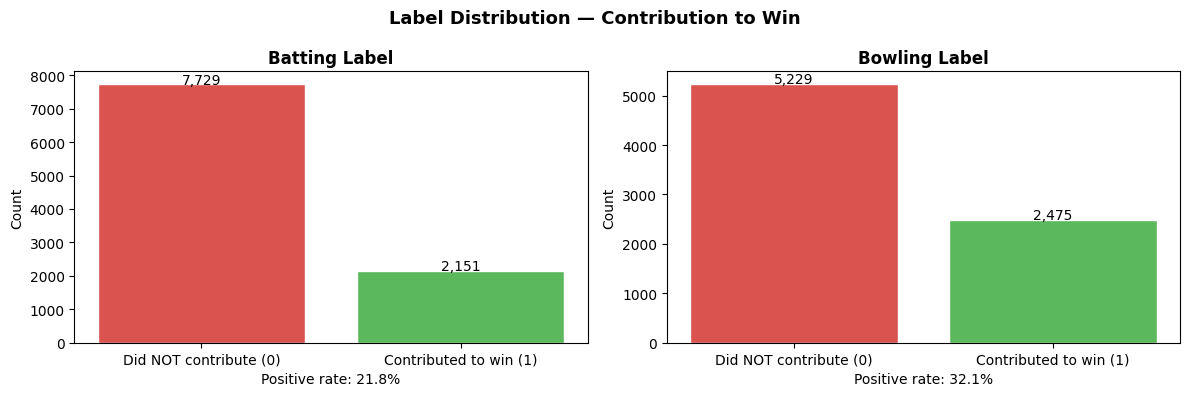

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df_plot, title, mask_col in zip(
    axes,
    [batting, bowling],
    ['Batting Label', 'Bowling Label'],
    ['did_bat', 'did_bowl']
):
    vc = df_plot[df_plot[mask_col] == 1]['contributed_to_win'].value_counts().sort_index()
    bars = ax.bar(
        ['Did NOT contribute (0)', 'Contributed to win (1)'],
        vc.values,
        color=['#d9534f', '#5cb85c'],
        edgecolor='white'
    )
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', fontsize=10)
    pos_rate = vc.get(1, 0) / vc.sum() * 100
    ax.set_xlabel(f'Positive rate: {pos_rate:.1f}%')

plt.suptitle('Label Distribution — Contribution to Win', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'label_distribution.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 5 — Sanity Check: Top Players by Contribution Rate

If the label makes sense, top IPL players should appear at the top of this list.

In [ ]:
print('=== TOP 15 BATSMEN BY WIN CONTRIBUTION RATE (min 15 matches) ===')
bat_rate = (
    batting[batting['did_bat'] == 1]
    .groupby('player')
    .agg(
        matches      = ('match_id',            'count'),
        contrib_wins = ('contributed_to_win',  'sum'),
        avg_runs     = ('runs',                'mean'),
        avg_sr       = ('strike_rate',         'mean'),
    )
    .reset_index()
)
bat_rate = bat_rate[bat_rate['matches'] >= 15].copy()
bat_rate['contrib_rate'] = bat_rate['contrib_wins'] / bat_rate['matches']
bat_rate = bat_rate.sort_values('contrib_rate', ascending=False)

print(bat_rate.head(15).round(2).to_string(index=False))

=== TOP 15 BATSMEN BY WIN CONTRIBUTION RATE (min 15 matches) ===
         player  matches  contrib_wins  avg_runs  avg_sr  contrib_rate
        PD Salt       34            16     31.06  151.03          0.47
B Sai Sudharsan       40            17     44.82  139.26          0.42
     RD Gaikwad       70            29     35.74  110.86          0.41
  SE Rutherford       20             8     19.85  137.96          0.40
J Fraser-McGurk       15             6     25.67  156.90          0.40
      DP Conway       28            11     38.57  110.06          0.39
  Priyansh Arya       18             7     30.28  150.94          0.39
       S Dhawan      126            47     33.24  114.75          0.37
   F du Plessis      108            40     34.19  122.94          0.37
   Shubman Gill      114            42     33.91  124.60          0.37
        V Kohli      144            52     38.40  122.90          0.36
       KL Rahul      117            42     41.94  129.96          0.36
      Q de K

In [ ]:
print('=== TOP 15 BOWLERS BY WIN CONTRIBUTION RATE (min 15 matches) ===')
bowl_rate = (
    bowling[bowling['did_bowl'] == 1]
    .groupby('player')
    .agg(
        matches      = ('match_id',            'count'),
        contrib_wins = ('contributed_to_win',  'sum'),
        avg_economy  = ('economy',             'mean'),
        avg_wickets  = ('wickets',             'mean'),
    )
    .reset_index()
)
bowl_rate = bowl_rate[bowl_rate['matches'] >= 15].copy()
bowl_rate['contrib_rate'] = bowl_rate['contrib_wins'] / bowl_rate['matches']
bowl_rate = bowl_rate.sort_values('contrib_rate', ascending=False)

print(bowl_rate.head(15).round(2).to_string(index=False))

=== TOP 15 BOWLERS BY WIN CONTRIBUTION RATE (min 15 matches) ===
          player  matches  contrib_wins  avg_economy  avg_wickets  contrib_rate
         L Ngidi       16            11         8.72         2.00          0.69
 Shakib Al Hasan       38            20         8.16         0.74          0.53
 NM Coulter-Nile       25            13         8.10         1.32          0.52
     Imran Tahir       43            22         7.68         1.40          0.51
      SL Malinga       24            12         9.17         1.21          0.50
    JR Hazlewood       39            19         8.45         1.49          0.49
     Rashid Khan      136            66         7.32         1.22          0.49
         J Yadav       17             8         7.38         0.41          0.47
        CV Varun       83            39         7.89         1.23          0.47
       JJ Bumrah      128            60         7.19         1.49          0.47
        MA Starc       24            11        10.86   

> **What to look for:** Recognised IPL impact players should appear in the top 15. If unknown or inactive players dominate, the label threshold is too loose — they're getting credit for easy wins.

## Step 6 — Save Labelled Datasets

In [ ]:
batting.to_parquet(PROCESSED_DIR + 'batting_labelled.parquet', index=False)
bowling.to_parquet(PROCESSED_DIR + 'bowling_labelled.parquet', index=False)

print('Saved:')
print(f'  batting_labelled.parquet — {len(batting):,} rows × {batting.shape[1]} cols')
print(f'  bowling_labelled.parquet — {len(bowling):,} rows × {bowling.shape[1]} cols')

Saved:
  batting_labelled.parquet — 9,886 rows × 40 cols
  bowling_labelled.parquet — 7,704 rows × 42 cols


## Step 7 — Validation Checks

In [ ]:
bat = pd.read_parquet(PROCESSED_DIR + 'batting_labelled.parquet')
bwl = pd.read_parquet(PROCESSED_DIR + 'bowling_labelled.parquet')

bat_pos_rate  = bat[bat['did_bat']==1]['contributed_to_win'].mean()
bowl_pos_rate = bwl[bwl['did_bowl']==1]['contributed_to_win'].mean()

checks = [
    ('contributed_to_win exists in batting',   'contributed_to_win' in bat.columns),
    ('contributed_to_win exists in bowling',   'contributed_to_win' in bwl.columns),
    ('batting label has no nulls',             bat['contributed_to_win'].isnull().sum() == 0),
    ('bowling label has no nulls',             bwl['contributed_to_win'].isnull().sum() == 0),
    ('batting positive rate 10-35%',           0.10 <= bat_pos_rate <= 0.35),
    ('bowling positive rate 10-35%',           0.10 <= bowl_pos_rate <= 0.35),
    ('individual_contributed exists (bat)',    'individual_contributed' in bat.columns),
    ('individual_contributed exists (bowl)',   'individual_contributed' in bwl.columns),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result:
        all_pass = False

print(f'\n  Batting positive rate  : {bat_pos_rate:.1%}')
print(f'  Bowling positive rate  : {bowl_pos_rate:.1%}')
print()

if all_pass:
    print('All checks passed. Proceed to Notebook 04 — Batting Model.')
else:
    print('Fix failing checks before proceeding.')
    print('If positive rate is out of range, adjust thresholds in Step 1 and rerun.')

✓  contributed_to_win exists in batting
✓  contributed_to_win exists in bowling
✓  batting label has no nulls
✓  bowling label has no nulls
✓  batting positive rate 10-35%
✓  bowling positive rate 10-35%
✓  individual_contributed exists (bat)
✓  individual_contributed exists (bowl)

  Batting positive rate  : 21.8%
  Bowling positive rate  : 32.1%

All checks passed. Proceed to Notebook 04 — Batting Model.
